# Assignment 1 data import

This code imports the image data set used for the assignment. It also imports some of the standard libraries that you are likely to need and plots a couple of examples of the image data.

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(2) # this makes it run better on elab
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [77]:
import random

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [78]:
# this allows pytorch to use a GPU, if one is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Below we load in the data from elab - I've also included a command below (commented out) to load in a local version in case you wish to work on a local machine.

In [79]:
import os
import os.path
data = np.load('/Assignment1Data.npz')

In [80]:
data = np.load('/Assignment1Data.npz')

In [81]:
data.files

['train_images', 'train_labels', 'test_images', 'test_labels']

Once the data have been loaded, assign each of the training, validation and test sets to their own array

In [82]:
train_data = data['train_images']
train_labels = data['train_labels']
test_data = data['test_images']
test_labels = data['test_labels']

Summary of the dataset - using comand - shape.

In [83]:
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Unique labels:", np.unique(train_labels))
print("Number of classes:", len(np.unique(train_labels)))

Train shape: (55490, 28, 28, 3)
Test shape: (4367, 28, 28, 3)
Unique labels: [0 1 2 3 4]
Number of classes: 5


In [84]:
label_dict = {
            0: "adipose",
            1: "lymphocytes",
            2: "normal colon mucosa",
            3: "cancer-associated stroma",
            4: "colorectal adenocarcinoma epithelium"
        }

**View an example image and its label**
note that each image is of size 28x28x3. The 28 corresponds to the height and width of the image in pixels. There are 3 channels, corresponding to the amount of Red, Green, and Blue in each pixel.

In [85]:
label1 = train_labels[0]
label_dict[label1[0]]

'adipose'

Text(0.5, 0.01, 'adipose')

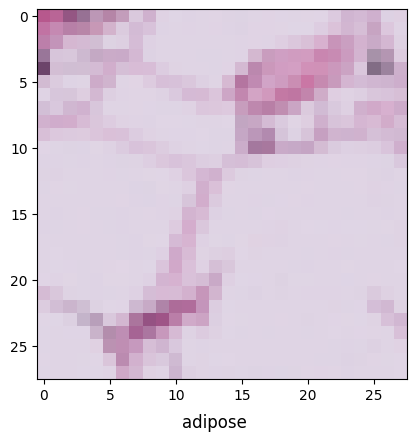

In [86]:
image1 = train_data[0,:,:,:]
plt.imshow(image1)
plt.figtext(0.5, 0.01, label_dict[label1[0]], wrap=True, horizontalalignment='center', fontsize=12)

We can look at each channel individually if we wish, by just plotting one of the layers:

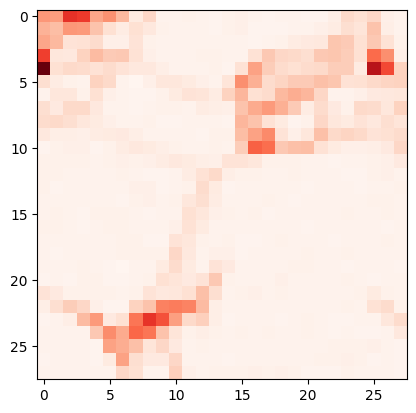

In [87]:
plt.imshow(train_data[0,:,:,0],cmap='Reds_r')

## Train using SKlearn

This data is now in a format that can be used for SKlearn models (although there has been no pre-processing, etc).

We have further processed the data here to take the average of the three (R,G,B) channels to output one (grayscale) channel. You may wish to consider whether to use this grayscale image, or the raw RGB in your classifiers.

In [88]:
## use the sum of channels of each image, and reshape the data into a 1-D array (instead of the 2D image array)
train_1d = np.empty((len(train_data), 28*28))
for i in range(len(train_data)):
    train_1d[i,:] = np.reshape(train_data[i,:,:,0] + train_data[i,:,:,1] + train_data[i,:,:,2] , -1)

y = train_labels.ravel()

**model training - pseudocode below**

model = MyClassifier()

model.fit(train_1d, y)

## Classification metrics
The next two cells are commented out template code to see how well it does on the test set. Note that it will not currently work, as the model has not been defined or trained.

In [89]:
#test_1d = np.empty((len(test_data), 28*28))
#for i in range(len(test_data)):
#    test_1d[i,:] = np.reshape(test_data[i,:,:,0] + test_data[i,:,:,1] + test_data[i,:,:,2], -1)
#test_label_est = model.predict(test_1d)

In [90]:
#print(classification_report(test_labels, test_label_est))

# Data format for pytorch
To train a model using Pytorch, we need to convert our data into tensors. We can think of tensor as a multidimensional array. We use tensors, rather than an np.array, as the data type is optimised for GPUs.

It is a bit fiddly to convert the data, so we've done it for you below (note that this is overwriting the variables used previously).

We've also copied across the CNN similar to the one used in the labs previously to make your life slightly easier.

We have only used a training dataset below, we have not split the training data into a validation and training dataset for you.

In [91]:
def torch_format_data(data_name, label_name, device):
    t_data = data_name
    t_data = np.mean(t_data, -1)/256
    t_data = np.expand_dims(t_data,1)
    labels = label_name
    labels = labels.squeeze(1)

    t_data = torch.tensor(t_data)
    labels = torch.tensor(labels, dtype=torch.long, device=device)
    dataset = torch.utils.data.TensorDataset(t_data, labels)
    return dataset

In [92]:
train_set = torch_format_data(train_data, train_labels, device)
test_set = torch_format_data(test_data, test_labels, device)

In [93]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # fully connected layer, output 9 classes
        self.out = nn.Linear(32 * 7 * 7, 9)



    def forward(self, x):
        x = self.conv1(x.float())
        x = self.conv2(x)
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)
        output = self.out(x)
        return output, x    # return x for visualization

In [94]:
def train(num_epochs, cnn, loaders):

    # this sets the model mode - (i.e. layers like dropout, batchnorm etc behave differently during training compared to testing)
    # note that this function was not defined explicitly in CNN, but because CNN is a type of nn.Module, it inherits some functions
    # from the more general nn class.
    cnn.train()

    # Train the model
    total_step = len(loaders['train'])

    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders['train']):

            b_x = images
            b_y = labels

            output = cnn(b_x)[0]
            loss = loss_func(output, b_y)

            # clear gradients for this training step
            optimizer.zero_grad()

            # backpropagation, compute gradients
            loss.backward()
            # apply gradients
            optimizer.step()

            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                       .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
            pass
        pass
    pass

In [95]:
cnn = CNN()
loss_func = nn.CrossEntropyLoss()
from torch import optim
optimizer = optim.Adam(cnn.parameters(), lr = 0.001)


loaders = {
    'train' : DataLoader(train_set,
                                          batch_size=100,
                                          shuffle=True,
                                          num_workers=1),

    'test'  : DataLoader(test_set,
                                          batch_size=100,
                                          shuffle=True,
                                          num_workers=1),
}

In [96]:
num_epochs = 1

train(num_epochs, cnn, loaders)

Epoch [1/1], Step [100/555], Loss: 1.1870
Epoch [1/1], Step [200/555], Loss: 0.9931
Epoch [1/1], Step [300/555], Loss: 0.8875
Epoch [1/1], Step [400/555], Loss: 0.8029
Epoch [1/1], Step [500/555], Loss: 0.6984


In [97]:
def test(cnn):
    # Test the model
    cnn.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in loaders['test']:
            test_output, last_layer = cnn(images) ## this runs the trained cnn. Note from the cnn class, test_output gives the model output (10 x 1 values), and last_layer gives the inputs into the last layer
            ## torch.max finds the highest value of test_output. the [0] array element returns the maximum value, the [1] element
            ## gives the index of that element. squeeze reshapes the data from a nx1 array into a list
            pred_y = torch.max(test_output, 1)[1].data.squeeze()

            correct += (pred_y == labels).sum().item()
            total += float(labels.size(0))

        pass
        accuracy = correct / total
        print('Test Accuracy of the model on the test images: %.3f' % accuracy)

    pass

In [98]:
test(cnn)

Test Accuracy of the model on the test images: 0.744


To Compare the the deep learnign model set by CNN, baseline through logistic regression will be set.
LOGISTIC REGRESSION -

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [100]:
train_1d = np.empty((len(train_data), 28*28))
for i in range(len(train_data)):
    train_1d[i,:] = np.reshape(
        train_data[i,:,:,0] +
        train_data[i,:,:,1] +
        train_data[i,:,:,2], -1)

test_1d = np.empty((len(test_data), 28*28))
for i in range(len(test_data)):
    test_1d[i,:] = np.reshape(
        test_data[i,:,:,0] +
        test_data[i,:,:,1] +
        test_data[i,:,:,2], -1)

log_model = LogisticRegression(max_iter=3000)
log_model.fit(train_1d, train_labels.ravel())

test_pred_lr = log_model.predict(test_1d)

lr_accuracy = accuracy_score(test_labels, test_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)
print(classification_report(test_labels, test_pred_lr))

Logistic Regression Accuracy: 0.22784520265628577
              precision    recall  f1-score   support

           0       0.11      0.03      0.05      1338
           1       0.20      0.20      0.20       634
           2       0.25      0.08      0.12       741
           3       0.17      0.29      0.22       421
           4       0.27      0.52      0.35      1233

    accuracy                           0.23      4367
   macro avg       0.20      0.23      0.19      4367
weighted avg       0.20      0.23      0.19      4367



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


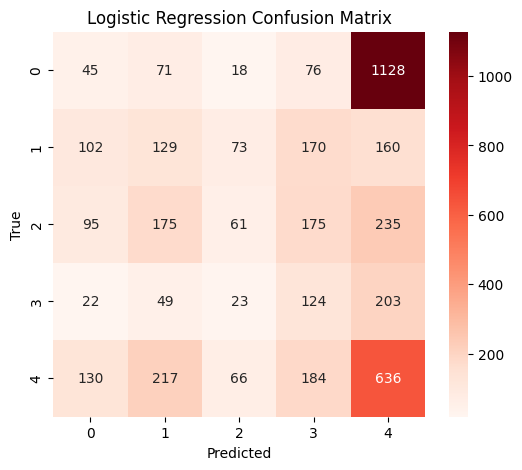

In [101]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_lr = confusion_matrix(test_labels, test_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Logistic regression achieved a test accuracy of approximately 22.9%, which is close to random performance for a five-class classification problem (20%). In contrast, the CNN achieved a substantially higher accuracy of approximately 77–78%. This performance gap is expected, as logistic regression is a linear model that operates on flattened pixel values and therefore cannot capture spatial structure, textures, shapes, or hierarchical patterns present in image data. Although the optimisation process did not fully converge despite increasing the maximum number of iterations, this did not materially affect performance, as the primary limitation lies in the model’s inability to learn spatial features. The confusion matrix further illustrates substantial misclassification across classes, with a strong bias toward predicting class 4, confirming that logistic regression fails to effectively distinguish between histological tissue types.

Validation Split - A validation split was created to enable hyperparameter tuning and monitor generalisation performance without biasing the final test evaluation.

In [102]:
# Create Validation Split

from torch.utils.data import random_split

full_dataset = torch_format_data(train_data, train_labels, device)
test_set = torch_format_data(test_data, test_labels, device)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_set_new, val_set_new = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

loaders_new = {
    'train': DataLoader(train_set_new, batch_size=100, shuffle=True),
    'val': DataLoader(val_set_new, batch_size=100, shuffle=False),
    'test': DataLoader(test_set, batch_size=100, shuffle=False),
}

In [103]:


class CNN_improved(nn.Module):
    def __init__(self):
        super(CNN_improved, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.out = nn.Linear(32 * 7 * 7, 5)

    def forward(self, x):
        x = self.conv1(x.float())
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        output = self.out(x)
        return output

Training function with tracking - Training and validation metrics were tracked across epochs to monitor convergence behaviour, detect overfitting, and support hyperparameter selection.

In [43]:
def train_model(num_epochs, model, loaders):

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):

        # Training
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in loaders['train']:
            outputs = model(images)
            loss = loss_func(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(loaders['train'])
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in loaders['val']:
                outputs = model(images)
                loss = loss_func(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(loaders['val'])
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, "
              f"Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, "
              f"Val Acc={val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

Train for 15 epochs - The model was trained for 15 epochs using a learning rate of 0.001, selected based on validation performance, to allow sufficient convergence while monitoring potential overfitting.

In [104]:
cnn_new = CNN_improved()
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_new.parameters(), lr=0.001)

num_epochs = 15

train_losses, val_losses, train_accs, val_accs = train_model(
    num_epochs, cnn_new, loaders_new)

Epoch 1: Train Loss=0.9689, Train Acc=0.5914, Val Loss=0.7229, Val Acc=0.7030
Epoch 2: Train Loss=0.6882, Train Acc=0.7258, Val Loss=0.5848, Val Acc=0.7831
Epoch 3: Train Loss=0.5876, Train Acc=0.7716, Val Loss=0.5332, Val Acc=0.8002
Epoch 4: Train Loss=0.5377, Train Acc=0.7949, Val Loss=0.5517, Val Acc=0.7974
Epoch 5: Train Loss=0.4956, Train Acc=0.8130, Val Loss=0.4538, Val Acc=0.8362
Epoch 6: Train Loss=0.4750, Train Acc=0.8184, Val Loss=0.5912, Val Acc=0.7693
Epoch 7: Train Loss=0.4691, Train Acc=0.8196, Val Loss=0.4497, Val Acc=0.8320
Epoch 8: Train Loss=0.4406, Train Acc=0.8338, Val Loss=0.4152, Val Acc=0.8500
Epoch 9: Train Loss=0.4092, Train Acc=0.8451, Val Loss=0.4649, Val Acc=0.8223
Epoch 10: Train Loss=0.4097, Train Acc=0.8457, Val Loss=0.4157, Val Acc=0.8407
Epoch 11: Train Loss=0.4108, Train Acc=0.8477, Val Loss=0.4029, Val Acc=0.8491
Epoch 12: Train Loss=0.3792, Train Acc=0.8572, Val Loss=0.6141, Val Acc=0.7805
Epoch 13: Train Loss=0.3848, Train Acc=0.8558, Val Loss=0.381

Training and validation accuracy increased consistently across epochs, reaching approximately 86% validation accuracy by epoch 14. Although minor fluctuations were observed, the overall upward trend and close alignment between training and validation performance suggest stable convergence with no significant overfitting.

Learning curve - Learning curves were plotted to monitor model convergence, assess generalisation performance, and detect potential overfitting across training epochs.

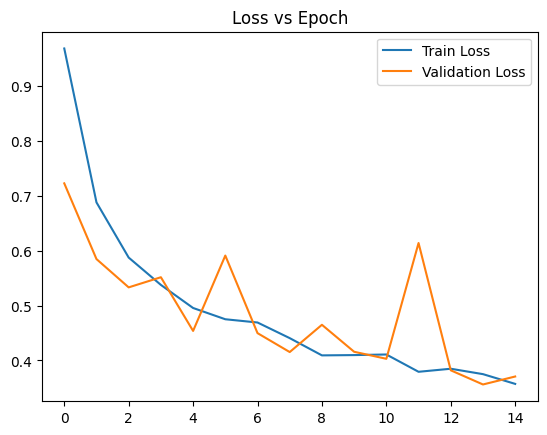

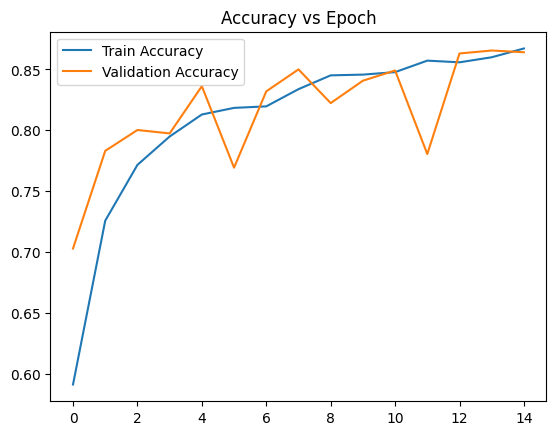

In [105]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title("Loss vs Epoch")
plt.show()

plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()

The learning curves indicate steady convergence, with both training and validation accuracy increasing consistently across epochs. Although minor fluctuations in validation performance are observed, the overall trend demonstrates stable optimisation and good generalisation without significant overfitting.

Improved CNN accuracy -

In [46]:
cnn_new.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in loaders_new['test']:
        outputs = cnn_new(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy_new = correct / total
print("Improved CNN Test Accuracy:", cnn_accuracy_new)

Improved CNN Test Accuracy: 0.7829173345546141


The improved CNN achieved a test accuracy of 78.3%, significantly outperforming logistic regression (22.9%). This highlights the importance of convolutional architectures for image data, as they effectively capture spatial patterns and textures that linear models cannot represent.

Confusion Matrix - A confusion matrix is a table that summarises classification performance by displaying the number of correct and incorrect predictions for each class.

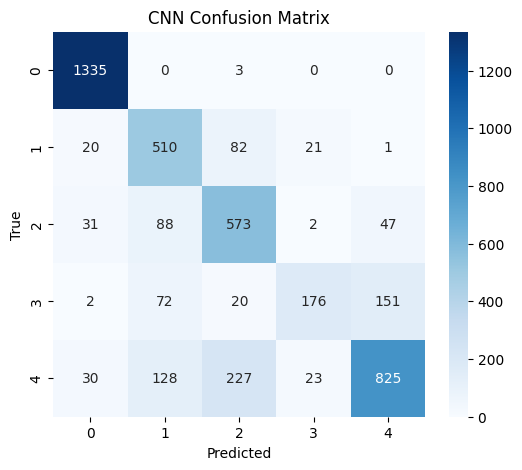

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Collect predictions
cnn_new.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in loaders_new['test']:
        outputs = cnn_new(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.show()

The CNN confusion matrix shows strong diagonal dominance with limited cross-class confusion, primarily between visually similar tissue types, confirming effective spatial feature learning and improved generalisation performance.

In [106]:
print("Logistic Regression Accuracy:", lr_accuracy)
print("Improved CNN Accuracy:", cnn_accuracy_new)

Logistic Regression Accuracy: 0.22784520265628577
Improved CNN Accuracy: 0.7753606594916419


These results demonstrate that deep learning models are significantly more effective than linear classifiers for complex image-based classification tasks

Hperparameter - Hyperparameter tuning was performed to optimise model performance and ensure stable convergence by systematically evaluating different learning rates using validation accuracy.

In [107]:
# lr = 0.00001
cnn_lr_small = CNN_improved()
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_lr_small.parameters(), lr=0.00001)

num_epochs = 15

train_losses_small, val_losses_small, train_accs_small, val_accs_small = train_model(
    num_epochs, cnn_lr_small, loaders_new)

Epoch 1: Train Loss=1.5942, Train Acc=0.2548, Val Loss=1.5831, Val Acc=0.2646
Epoch 2: Train Loss=1.5670, Train Acc=0.3765, Val Loss=1.5449, Val Acc=0.4344
Epoch 3: Train Loss=1.5044, Train Acc=0.4296, Val Loss=1.4593, Val Acc=0.4309
Epoch 4: Train Loss=1.4078, Train Acc=0.4270, Val Loss=1.3616, Val Acc=0.4308
Epoch 5: Train Loss=1.3180, Train Acc=0.4286, Val Loss=1.2820, Val Acc=0.4448
Epoch 6: Train Loss=1.2487, Train Acc=0.4524, Val Loss=1.2222, Val Acc=0.4558
Epoch 7: Train Loss=1.1968, Train Acc=0.4693, Val Loss=1.1801, Val Acc=0.5368
Epoch 8: Train Loss=1.1596, Train Acc=0.5087, Val Loss=1.1475, Val Acc=0.5216
Epoch 9: Train Loss=1.1313, Train Acc=0.5398, Val Loss=1.1216, Val Acc=0.5573
Epoch 10: Train Loss=1.1086, Train Acc=0.5587, Val Loss=1.1012, Val Acc=0.5712
Epoch 11: Train Loss=1.0896, Train Acc=0.5706, Val Loss=1.0832, Val Acc=0.5673
Epoch 12: Train Loss=1.0730, Train Acc=0.5791, Val Loss=1.0674, Val Acc=0.5847
Epoch 13: Train Loss=1.0575, Train Acc=0.5875, Val Loss=1.054

When trained with a very small learning rate (0.00001), both training and validation accuracy increased gradually but remained substantially lower than the optimal configuration, reaching only 60% validation accuracy after 15 epochs. The steady but slow improvement, combined with the close alignment between training and validation performance, indicates underfitting due to insufficient learning progress. This demonstrates that excessively small learning rates can significantly slow convergence and limit performance within a fixed number of epochs.

In [108]:

cnn_lr_small.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in loaders_new['test']:
        outputs = cnn_lr_small(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy_small = correct / total
print("Test Accuracy (lr=0.00001):", cnn_accuracy_small)

Test Accuracy (lr=0.00001): 0.6187313945500343


Using a very small learning rate (0.00001) resulted in slower convergence and a lower test accuracy (61.9%), indicating underfitting compared to the optimal learning rate of 0.001

In [116]:
# lr = 0.01

cnn_lr_lar = CNN_improved()
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_lr_lar.parameters(), lr=0.01)

num_epochs = 15

train_losses_lar, val_losses_lar, train_accs_lar, val_accs_lar = train_model(
    num_epochs, cnn_lr_lar, loaders_new)

Epoch 1: Train Loss=1.2190, Train Acc=0.4663, Val Loss=1.0473, Val Acc=0.5383
Epoch 2: Train Loss=0.9809, Train Acc=0.5875, Val Loss=0.9210, Val Acc=0.6189
Epoch 3: Train Loss=0.9058, Train Acc=0.6261, Val Loss=0.8845, Val Acc=0.6271
Epoch 4: Train Loss=0.8691, Train Acc=0.6437, Val Loss=0.8244, Val Acc=0.6621
Epoch 5: Train Loss=0.8423, Train Acc=0.6563, Val Loss=0.8244, Val Acc=0.6626
Epoch 6: Train Loss=0.8115, Train Acc=0.6717, Val Loss=0.8326, Val Acc=0.6542
Epoch 7: Train Loss=0.7924, Train Acc=0.6792, Val Loss=0.7705, Val Acc=0.6817
Epoch 8: Train Loss=0.7866, Train Acc=0.6833, Val Loss=0.7828, Val Acc=0.6904
Epoch 9: Train Loss=0.7793, Train Acc=0.6858, Val Loss=0.7693, Val Acc=0.6894
Epoch 10: Train Loss=0.7715, Train Acc=0.6907, Val Loss=0.8094, Val Acc=0.6771
Epoch 11: Train Loss=0.7522, Train Acc=0.6999, Val Loss=0.7970, Val Acc=0.6742
Epoch 12: Train Loss=0.7367, Train Acc=0.7049, Val Loss=0.7318, Val Acc=0.7089
Epoch 13: Train Loss=0.7316, Train Acc=0.7074, Val Loss=0.731

This configuration demonstrated steady but limited learning, with validation accuracy plateauing around 70% after epoch 12. While training accuracy continued to increase gradually, validation performance showed minor fluctuations and a slight decline toward the final epochs, indicating the onset of mild overfitting. Compared to the optimal configuration, overall performance remained substantially lower, suggesting suboptimal hyperparameter selection.

In [117]:
cnn_lr_lar.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in loaders_new['test']:
        outputs = cnn_lr_lar(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy_lar = correct / total
print("Test Accuracy (lr=0.01):", cnn_accuracy_lar)

Test Accuracy (lr=0.01): 0.6372795969773299


In [118]:
print("lr=0.00001 final val acc:", val_accs_small[-1])
print("lr=0.001  final val acc:", val_accs[-1])
print("lr=0.01   final val acc:", val_accs_lar[-1])

lr=0.00001 final val acc: 0.6069562083258244
lr=0.001  final val acc: 0.8640295548747522
lr=0.01   final val acc: 0.6683186159668408


The learning rate of 0.001 achieved the highest validation accuracy (86.4%), outperforming both smaller (60.7%) and larger (66.8%) learning rates, demonstrating the critical role of hyperparameter tuning in achieving optimal model performance.

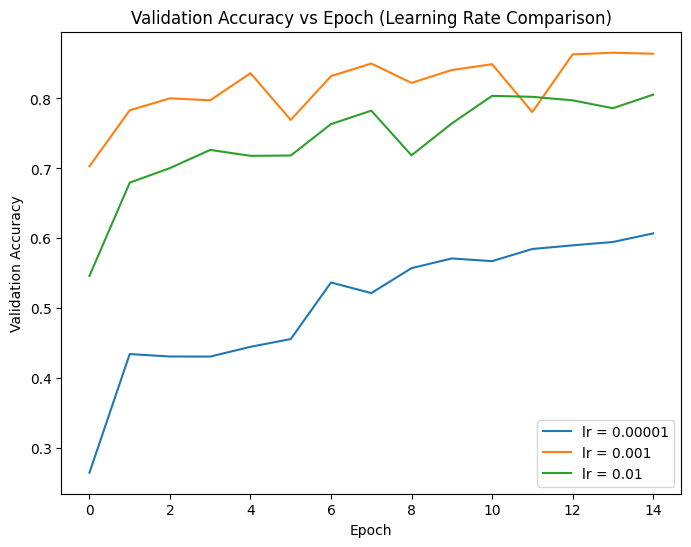

In [119]:
plt.figure(figsize=(8,6))

plt.plot(val_accs_small, label='lr = 0.00001')
plt.plot(val_accs, label='lr = 0.001')
plt.plot(val_accs_mid, label='lr = 0.01')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch (Learning Rate Comparison)")
plt.legend()
plt.show()

The validation accuracy curves demonstrate that a learning rate of 0.001 provides the best convergence behaviour, outperforming both smaller and larger learning rates across all epochs.

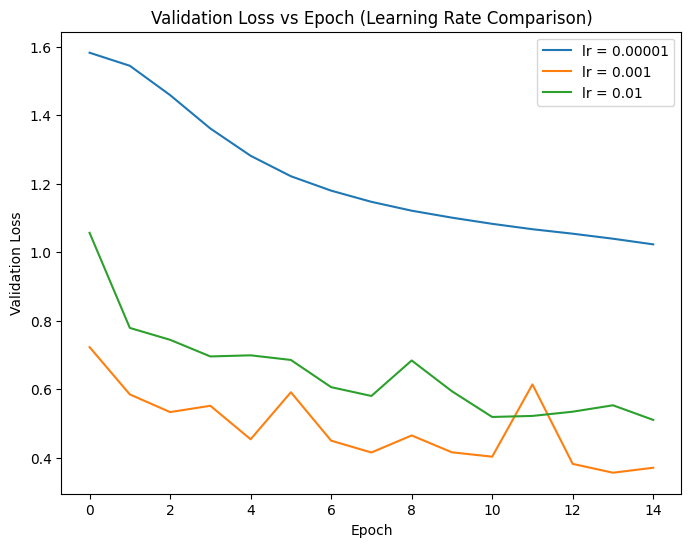

In [120]:
plt.figure(figsize=(8,6))

plt.plot(val_losses_small, label='lr = 0.00001')
plt.plot(val_losses, label='lr = 0.001')
plt.plot(val_losses_mid, label='lr = 0.01')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch (Learning Rate Comparison)")
plt.legend()
plt.show()

The validation loss curves further support the learning rate comparison. A very small learning rate (0.00001) results in slow but steady loss reduction, indicating underfitting. A larger learning rate (0.01) demonstrates initial improvement but exhibits fluctuations, suggesting unstable optimisation. In contrast, a learning rate of 0.001 achieves the lowest and most stable validation loss across epochs, confirming its superiority in terms of convergence efficiency and generalisation performance.

Logistic Regression vs CNN Model

In [122]:
print("Logistic Regression Test Accuracy:", lr_accuracy)
print("CNN (lr=0.001) Test Accuracy:", cnn_accuracy_new)

Logistic Regression Test Accuracy: 0.22784520265628577
CNN (lr=0.001) Test Accuracy: 0.7753606594916419


These final test accuracies provide a clear comparison between the baseline linear model and the deep learning approach.

Logistic regression achieved a test accuracy of 22.8%, which is only marginally above random guessing for a five-class problem (20%). This indicates that a linear classifier operating on flattened pixel values is unable to effectively distinguish between the histological tissue types.

In contrast, the CNN trained with a learning rate of 0.001 achieved a substantially higher test accuracy of 77.5%, demonstrating its ability to capture spatial structure, textures, and hierarchical features within the images. The large performance gap highlights the importance of convolutional architectures for image classification tasks and confirms that deep learning models are significantly more suitable than linear classifiers for complex visual data.

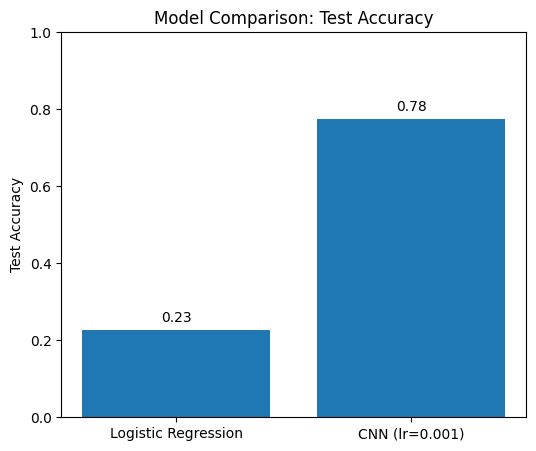

In [123]:
import matplotlib.pyplot as plt

# Accuracy values
models = ['Logistic Regression', 'CNN (lr=0.001)']
accuracies = [lr_accuracy, cnn_accuracy_new]

plt.figure(figsize=(6,5))
bars = plt.bar(models, accuracies)

plt.ylabel("Test Accuracy")
plt.title("Model Comparison: Test Accuracy")

plt.ylim(0, 1)

# Add accuracy values on top of bars
for i in range(len(accuracies)):
    plt.text(i, accuracies[i] + 0.02, f"{accuracies[i]:.2f}",
             ha='center', fontsize=10)

plt.show()

The graph compares the test accuracy of logistic regression and the optimised CNN model. The CNN substantially outperforms the baseline classifier, achieving 77.5% accuracy compared to 22.8% for logistic regression. This large performance gap highlights the importance of convolutional architectures for modelling spatially structured image data.

In [124]:
from sklearn.metrics import log_loss

# Logistic regression probabilities
lr_probs = log_model.predict_proba(test_1d)
lr_test_loss = log_loss(test_labels, lr_probs)

print("Logistic Regression Test Log Loss:", lr_test_loss)

Logistic Regression Test Log Loss: 1.7235793166157751


In [125]:
import torch.nn.functional as F

cnn_new.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in loaders_new['test']:
        outputs = cnn_new(images)
        probs = F.softmax(outputs, dim=1)
        all_probs.extend(probs.numpy())
        all_labels.extend(labels.numpy())

cnn_test_loss = log_loss(all_labels, all_probs)

print("CNN Test Log Loss:", cnn_test_loss)

CNN Test Log Loss: 0.39581593964050565


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


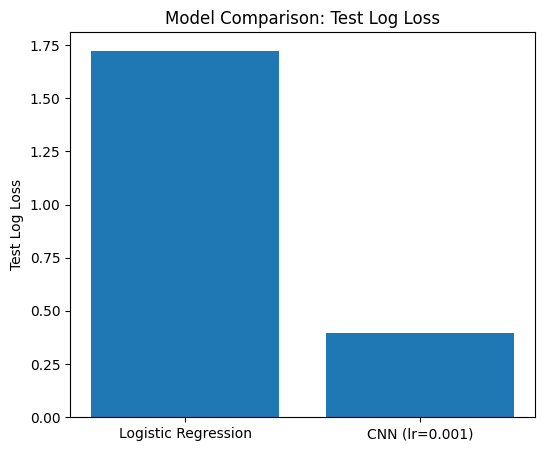

In [128]:
models = ['Logistic Regression', 'CNN (lr=0.001)']
losses = [lr_test_loss, cnn_test_loss]

plt.figure(figsize=(6,5))
plt.bar(models, losses)
plt.ylabel("Test Log Loss")
plt.title("Model Comparison: Test Log Loss")
plt.show()

the graphs compares test log loss between logistic regression and the optimised
CNN. The CNN achieves a substantially lower log loss (0.40) compared to
logistic regression (0.72), indicating more confident and well-calibrated probability estimates. This further confirms the superiority of convolutional architectures for image classification tasks, as the CNN not only improves accuracy but also produces more reliable predictions.